<a href="https://colab.research.google.com/github/Schachkatzen29/Phoenix-Heat-Waves/blob/main/Phoenix%20Heat%20Waves" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

pd.set_option('display.max_rows', 50)
plt.rcParams['figure.figsize'] = (12, 5)

In [3]:
# If you uploaded via the Colab file browser (folder icon on the left sidebar),
# the file lives in /content/ by default
filename = '/content/4304112.csv'

# Quick sanity check that the file is actually there
import os
if os.path.exists(filename):
    print(f"Found: {filename}")
    print(f"Size: {os.path.getsize(filename) / 1024:.1f} KB")
else:
    print(f"NOT FOUND: {filename}")
    print("\nFiles currently in /content/:")
    for f in os.listdir('/content/'):
        print(f"  {f}")

Found: /content/4304112.csv
Size: 1695.7 KB


In [4]:
df = pd.read_csv(filename)
print("Columns:", df.columns.tolist())
print("Shape:", df.shape)
df.head()

Columns: ['STATION', 'NAME', 'DATE', 'TMAX', 'TMIN']
Shape: (27878, 5)


,STATION,NAME,DATE,TMAX,TMIN
0,USW00023183,"PHOENIX AIRPORT, AZ US",1950-01-01,70,54.0
1,USW00023183,"PHOENIX AIRPORT, AZ US",1950-01-02,66,54.0
2,USW00023183,"PHOENIX AIRPORT, AZ US",1950-01-03,55,25.0
3,USW00023183,"PHOENIX AIRPORT, AZ US",1950-01-04,47,19.0
4,USW00023183,"PHOENIX AIRPORT, AZ US",1950-01-05,51,17.0


In [5]:
# Parse dates
df['DATE'] = pd.to_datetime(df['DATE'])

# Keep only date and TMAX, drop missing
df = df[['DATE', 'TMAX']].dropna()

# Quick sanity check on units — Phoenix summer highs should be ~100-115°F or ~38-46°C
print("TMAX min:", df['TMAX'].min(), "TMAX max:", df['TMAX'].max())

# If max is over 200, the data is in tenths of degrees C — convert to F
# If max is between 110-125, it's already in F
# If max is between 40-50, it's in C
if df['TMAX'].max() > 200:
    df['TMAX'] = df['TMAX'] / 10 * 9/5 + 32  # tenths C to F
    print("Converted from tenths °C to °F")
elif df['TMAX'].max() < 60:
    df['TMAX'] = df['TMAX'] * 9/5 + 32  # C to F
    print("Converted from °C to °F")
else:
    print("Already in °F")

print("After conversion — TMAX min:", df['TMAX'].min(), "TMAX max:", df['TMAX'].max())

# Add helper columns
df['YEAR'] = df['DATE'].dt.year
df['DOY'] = df['DATE'].dt.dayofyear  # day of year, 1-366

df = df.sort_values('DATE').reset_index(drop=True)
df.head()

TMAX min: 43 TMAX max: 122
Already in °F
After conversion — TMAX min: 43 TMAX max: 122


,DATE,TMAX,YEAR,DOY
0,1950-01-01,70,1950,1
1,1950-01-02,66,1950,2
2,1950-01-03,55,1950,3
3,1950-01-04,47,1950,4
4,1950-01-05,51,1950,5


In [6]:
# Parse dates
df['DATE'] = pd.to_datetime(df['DATE'])

# Keep only date and TMAX, drop missing
df = df[['DATE', 'TMAX']].dropna()

# Quick sanity check on units — Phoenix summer highs should be ~100-115°F or ~38-46°C
print("TMAX min:", df['TMAX'].min(), "TMAX max:", df['TMAX'].max())

# If max is over 200, the data is in tenths of degrees C — convert to F
# If max is between 110-125, it's already in F
# If max is between 40-50, it's in C
if df['TMAX'].max() > 200:
    df['TMAX'] = df['TMAX'] / 10 * 9/5 + 32  # tenths C to F
    print("Converted from tenths °C to °F")
elif df['TMAX'].max() < 60:
    df['TMAX'] = df['TMAX'] * 9/5 + 32  # C to F
    print("Converted from °C to °F")
else:
    print("Already in °F")

print("After conversion — TMAX min:", df['TMAX'].min(), "TMAX max:", df['TMAX'].max())

# Add helper columns
df['YEAR'] = df['DATE'].dt.year
df['DOY'] = df['DATE'].dt.dayofyear  # day of year, 1-366

df = df.sort_values('DATE').reset_index(drop=True)
df.head()

TMAX min: 43 TMAX max: 122
Already in °F
After conversion — TMAX min: 43 TMAX max: 122


,DATE,TMAX,YEAR,DOY
0,1950-01-01,70,1950,1
1,1950-01-02,66,1950,2
2,1950-01-03,55,1950,3
3,1950-01-04,47,1950,4
4,1950-01-05,51,1950,5


In [8]:
# Use 1981-2010 as the climate baseline (standard 30-year reference period)
baseline = df[(df['YEAR'] >= 1981) & (df['YEAR'] <= 2010)].copy()

# For each day-of-year, compute the 90th percentile using a 15-day window
thresholds = {}
for doy in range(1, 367):
    # Days within ±7 of this day-of-year (handle year wrap)
    window_doys = [(doy + offset - 1) % 366 + 1 for offset in range(-7, 8)]
    window_data = baseline[baseline['DOY'].isin(window_doys)]['TMAX']
    if len(window_data) > 0:
        thresholds[doy] = np.percentile(window_data, 90)
    else:
        thresholds[doy] = np.nan

# Map threshold back onto the full dataframe
df['THRESHOLD_90'] = df['DOY'].map(thresholds)

# Flag exceedances# Find runs of consecutive exceedance days
df['STREAK_ID'] = (df['EXCEEDS'] != df['EXCEEDS'].shift()).cumsum()

streaks = (df[df['EXCEEDS']]
           .groupby('STREAK_ID')
           .agg(start=('DATE', 'min'),
                end=('DATE', 'max'),
                duration=('DATE', 'count'),
                peak_temp=('TMAX', 'max'),
                avg_excess=('TMAX', lambda x: (x - df.loc[x.index, 'THRESHOLD_90']).mean()))
           .reset_index(drop=True))

# Heat wave = 3+ consecutive days
heat_waves = streaks[streaks['duration'] >= 3].copy()
heat_waves['year'] = heat_waves['start'].dt.year

print(f"Total heat waves detected: {len(heat_waves)}")
print(f"\nLongest heat waves on record:")
print(heat_waves.nlargest(10, 'duration')[['start', 'end', 'duration', 'peak_temp']].to_string(index=False))
df['EXCEEDS'] = df['TMAX'] >= df['THRESHOLD_90']

print("Sample of summer thresholds:")
for doy in [152, 182, 213, 244]:  # June 1, July 1, Aug 1, Sep 1
    print(f"  DOY {doy}: 90th percentile = {thresholds[doy]:.1f}°F")

Total heat waves detected: 408

Longest heat waves on record:
     start        end  duration  peak_temp
2024-09-23 2024-10-16        24        117
1950-12-08 1950-12-26        19         88
2026-03-12 2026-03-30        19        105
2023-07-13 2023-07-30        18        119
1995-07-25 1995-08-10        17        121
2025-12-09 2025-12-23        15         83
1980-12-22 1981-01-03        13         85
2007-03-07 2007-03-19        13         99
2017-03-09 2017-03-21        13         96
2026-01-31 2026-02-12        13         86
Sample of summer thresholds:
  DOY 152: 90th percentile = 108.0°F
  DOY 182: 90th percentile = 113.0°F
  DOY 213: 90th percentile = 111.0°F
  DOY 244: 90th percentile = 110.0°F


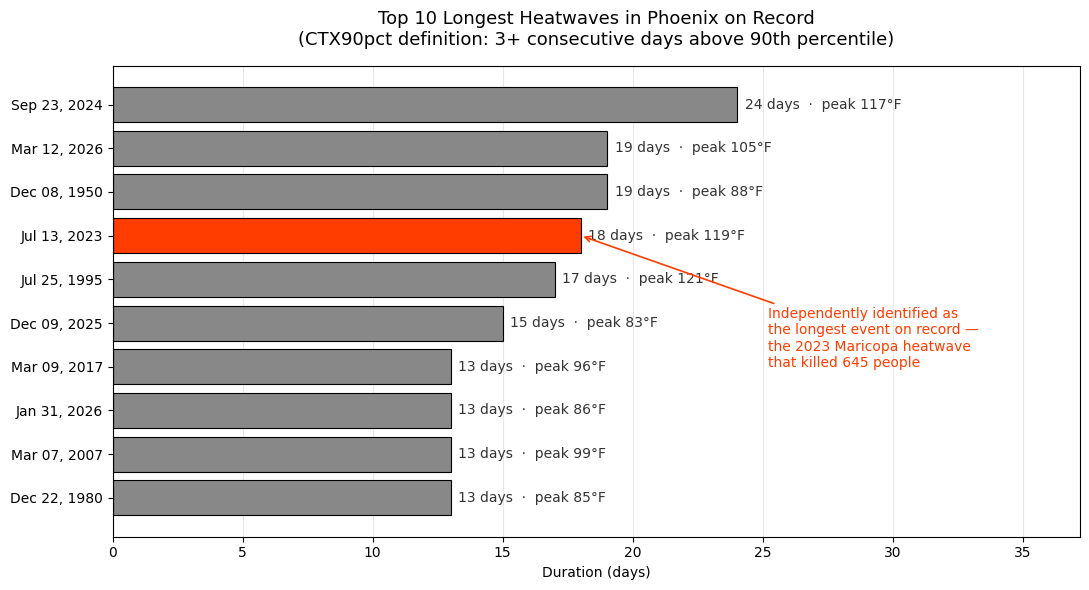

In [12]:
# Get top 10 longest heatwaves
top10 = heat_waves.nlargest(10, 'duration').copy()
top10 = top10.sort_values('duration')  # ascending so longest is at top of horizontal bar chart
top10['label'] = top10['start'].dt.strftime('%b %d, %Y')

# Highlight 2023
colors = ['#ff3d00' if y == 2023 else '#888888' for y in top10['year']]

plt.figure(figsize=(11, 6))
bars = plt.barh(top10['label'], top10['duration'], color=colors, edgecolor='black', linewidth=0.8)

# Annotate each bar with its duration
for bar, dur, peak in zip(bars, top10['duration'], top10['peak_temp']):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{int(dur)} days  ·  peak {peak:.0f}°F',
             va='center', fontsize=10, color='#333')

plt.title('Top 10 Longest Heatwaves in Phoenix on Record\n(CTX90pct definition: 3+ consecutive days above 90th percentile)',
          fontsize=13, pad=15)
plt.xlabel('Duration (days)')
plt.xlim(0, top10['duration'].max() * 1.55)
plt.grid(axis='x', alpha=0.3)
plt.gca().set_axisbelow(True)

# Add a callout for 2023
event_2023 = top10[top10['year'] == 2023]
if len(event_2023) > 0:
    longest_2023 = event_2023.iloc[-1]
    plt.annotate('Independently identified as\nthe longest event on record —\nthe 2023 Maricopa heatwave\nthat killed 645 people',
                 xy=(longest_2023['duration'], list(top10['label']).index(longest_2023['label'])),
                 xytext=(top10['duration'].max() * 1.05, 3),
                 fontsize=10, color='#ff3d00',
                 ha='left',
                 arrowprops=dict(arrowstyle='->', color='#ff3d00', lw=1.2))

plt.tight_layout()
plt.savefig('top10_heatwaves.png', dpi=150, bbox_inches='tight')
plt.show()

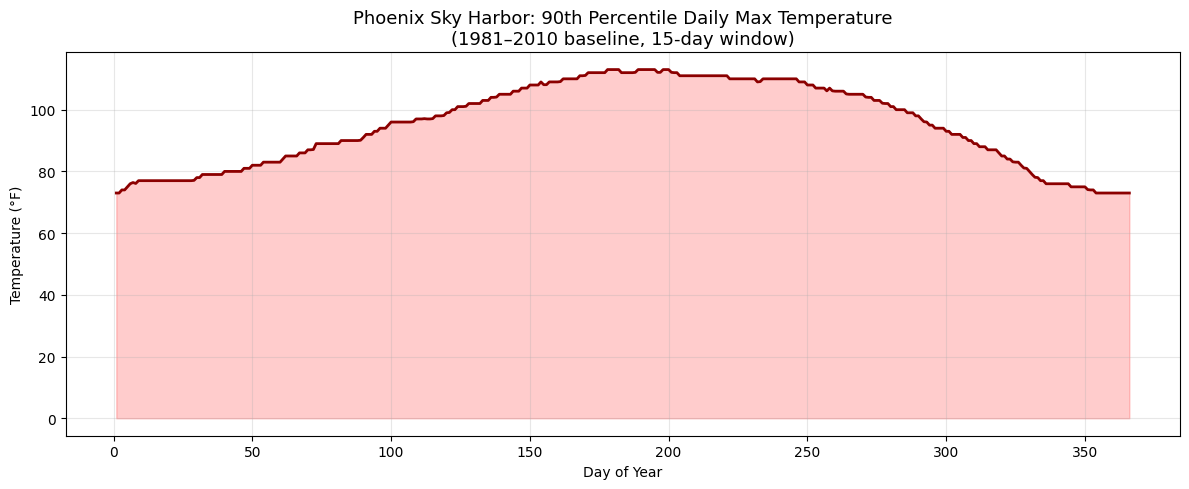

In [9]:
threshold_series = pd.Series(thresholds).sort_index()
day_labels = pd.date_range('2020-01-01', '2020-12-31').strftime('%b %d')

plt.figure(figsize=(12, 5))
plt.plot(threshold_series.index, threshold_series.values, color='darkred', linewidth=2)
plt.fill_between(threshold_series.index, threshold_series.values, alpha=0.2, color='red')
plt.title('Phoenix Sky Harbor: 90th Percentile Daily Max Temperature\n(1981–2010 baseline, 15-day window)', fontsize=13)
plt.xlabel('Day of Year')
plt.ylabel('Temperature (°F)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_curve.png', dpi=150, bbox_inches='tight')
plt.show()

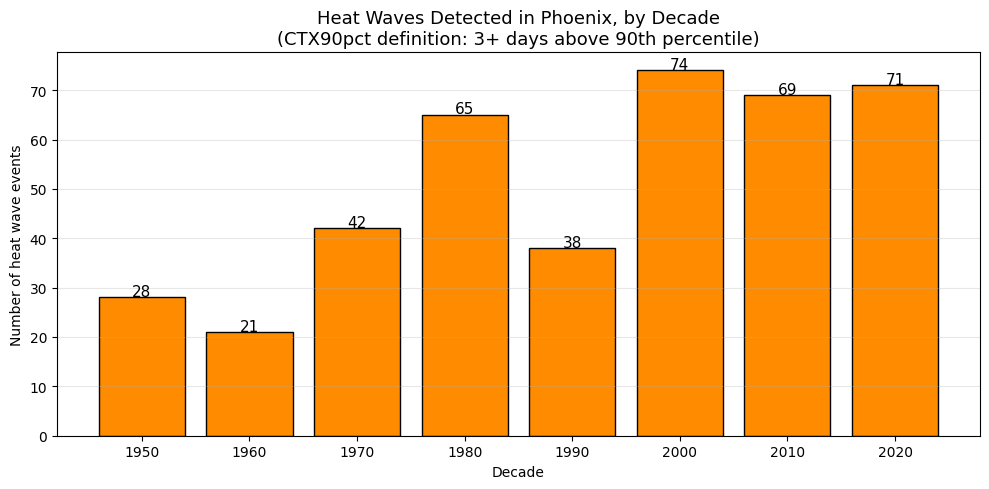

In [10]:
heat_waves['decade'] = (heat_waves['year'] // 10) * 10
by_decade = heat_waves.groupby('decade').size()

plt.figure(figsize=(10, 5))
bars = plt.bar(by_decade.index.astype(str), by_decade.values, color='darkorange', edgecolor='black')
plt.title('Heat Waves Detected in Phoenix, by Decade\n(CTX90pct definition: 3+ days above 90th percentile)', fontsize=13)
plt.xlabel('Decade')
plt.ylabel('Number of heat wave events')
plt.grid(axis='y', alpha=0.3)
for bar, value in zip(bars, by_decade.values):
    plt.text(bar.get_x() + bar.get_width()/2, value + 0.3, str(value),
             ha='center', fontsize=11)
plt.tight_layout()
plt.savefig('heat_waves_by_decade.png', dpi=150, bbox_inches='tight')
plt.show()